<a href="https://colab.research.google.com/github/AbhijeetBeedikar/Connect4-RL-Bot/blob/main/Connect4_Bot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle-environments

INFO: pip is looking at multiple versions of shimmy to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.8/953.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 840.2/840.2 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 M

##Monte Carlo Tree Search Algorithm

####Defining the Class to store each node




In [ ]:
from kaggle_environments import make
import math
import numpy as np
import copy
import pandas as pd


MCtree = {}
c = math.sqrt(2)
# model that the MCTS algorithm uses. Is this required?
model = make("connectx", debug=True)
model.reset()

def validActions(state): #kaggle env.state
  board = state[0]['observation']["board"]
  actions = []
  for i in range(7):
    if board[i] == 0:
      actions.append(True)
    else:
      actions.append(False)
  return actions
class MCTSNode:
  def __init__(self, state, action=None, parent=None):
    global model
    self.state = state
    self.action = action # action = None only for root node
    self.parent = parent # parent = None only for root node
                        # DEVELOPER NOTE: Parent field is not used. Update occurs recursively. Use parent field to iteratively backtrack
      # (s',a) for all a must be added to this list. If some (s',a) is missing then this is added as a leaf node and evaluated
    self.N = 0 # Number of times this node has been visited by the tree policy
    self.Q = 0 # We dont know much about the newly created node so we can keep bias 0 if we set this value as 0

    self.isRoot = True if self.parent == None else False
    tempModel = copy.deepcopy(model)
    tempModel.reset()
    tempModel.state = self.state
    if not self.isRoot:
      step = [None,None]
      player = int((self.state[0]["status"] != "ACTIVE")) # if player == red, then self.state[0]["status"] != "ACTIVE" --> False --> 0 --> index of the red player
      step[player] = self.action
      self.nextState = tempModel.step(step)
    else:
      self.nextState = self.state
    self.children = list(np.full(7,True)*validActions(self.nextState)) # add only MCTS nodes to this
    self.isTerminal = tempModel.done


  def addChild(self,child):
    self.children[child.action] = child

  @staticmethod
  def randRolloutPolicyReturn(tempModelForRollout): # this will never be called when the model inputted is at the terminal state
    '''
    returns the reward from a sample trajectory simulated based off of random action selection rollout policy
    '''

    if tempModelForRollout.done:
      return tempModelForRollout.state[0]["reward"] # we want the reward with respect to red only (because we negate this reward if a state is yellow)
    else:
      actionList = [int(i)*[0,1,2,3,4,5,6][index] for index,i in enumerate(validActions(tempModelForRollout.state)) if i]

      randAction = np.random.choice(actionList)

      p = int((tempModelForRollout.state[0]["status"] != "ACTIVE"))

      step = [None,None]
      step[p] = int(randAction)
      #print(validActions(tempModelForRollout.state))

      #FIX: Check whether any invalid moves were made or not

      tempModelForRollout.step(step)
      #tempModelForRollout.render(mode="ipython")

      return MCTSNode.randRolloutPolicyReturn(tempModelForRollout)

  def treeTraverse(self):
    '''Traverses along the Monte Carlo Tree. If called on the root, it performs an update along a trajectory based on
    the tree policy. Uses a rollout algorithm to update the value of a newly added leaf node and backs up this value along
    the tree trajectory. The reward backed up is different (opposite of each other) for the two colours.

    Must be called after each complete run (rollout + backup) of the MCTS algorithm'''
    global model
    global c
    action = None

    # Recursive Cases: Terminal, Leaf, root, intermediate fully expanded, intermediate semi-expanded

    # root case is handles by all the code blocks

    # Terminal Case
    if self.isTerminal: # True is not in self.children in the draw case (also covers win case)
      self.N +=1
      return self.Q

    # intermediate semi-expanded Case --> create a leaf node (covers leaf case)
    elif True in self.children: # When node is not fully expanded so a leaf node is created
      action = list(self.children).index(True)

      # set the model's state to the child's state for the constructor to work correctly when defining the child
      tempModel = copy.deepcopy(model)
      tempModel.reset()
      tempModel.state = self.nextState

      #add child (leaf node) to the list of children
      child = MCTSNode(self.nextState,action,self)

      self.addChild(child)

      # calculate the expected return using rollout algorithm
      rolloutReturn = 0
      for i in range(20):
        rolloutReturn += MCTSNode.randRolloutPolicyReturn(copy.deepcopy(tempModel)) #

      rolloutReturn /= 20

      # correctly assign the value of the expected return based on colour of the state of the new child
      # color of child.state represents whose turn it is when taking child.action
              # if red wins in the trajectory and this (state,action) node represents red taking an action,
              # then the cumulative reward for this node should be incremented by 1
      if child.state[0]["status"] == "ACTIVE":
        child.Q = rolloutReturn
      else:
        child.Q = -1*rolloutReturn


      self.N +=1

      return child.Q # return the value of the child calculated by the rollout policy (used in backup process)

    # intermediate expanded Case --> move to the next node using tree policy
    else: #UCT tree policy
      try:
        maxAction = []
        for i in self.children:
          if i == False:
            maxAct = -1*np.inf #action must never be taken
          elif i.N == 0:
            maxAct = np.inf # expansion
          else:
            maxAct = i.Q + c*math.sqrt(math.log(self.N)/i.N)
          maxAction.append(maxAct)
        action = np.argmax(maxAction)
        if len(maxAction) != 7:
          raise Exception(f"The number of actions to be evaluated by argmax is not correct: Expected 7 Got {len(maxAction)}")
      except:
        print(self.children)
        raise

      child = self.children[action]
      reward = child.treeTraverse()

      if self.state[0]["status"] == "ACTIVE": # if the state is red.
        self.Q += reward
      else: # if the state is not red i.e yellow
        self.Q -= reward
      self.N +=1
      return reward
# actual environment within which the agent makes decisions
env = make("connectx", debug=True) # TODO: first create MCTSNode(s) and branch it out to MCTS(s,a)--> MCTS(s',a')-->...
env.reset()



node = MCTSNode(model.state)

[kaggle_environments.envs.open_spiel.open_spiel] INFO: Successfully loaded OpenSpiel environments: 6.


INFO:kaggle_environments.envs.open_spiel.open_spiel:Successfully loaded OpenSpiel environments: 6.


[kaggle_environments.envs.open_spiel.open_spiel] INFO:    open_spiel_chess


INFO:kaggle_environments.envs.open_spiel.open_spiel:   open_spiel_chess


[kaggle_environments.envs.open_spiel.open_spiel] INFO:    open_spiel_connect_four


...

INFO:kaggle_environments.envs.open_spiel.open_spiel:   open_spiel_tic_tac_toe


[kaggle_environments.envs.open_spiel.open_spiel] INFO:    open_spiel_universal_poker


INFO:kaggle_environments.envs.open_spiel.open_spiel:   open_spiel_universal_poker


[kaggle_environments.envs.open_spiel.open_spiel] INFO: OpenSpiel games skipped: 0.


INFO:kaggle_environments.envs.open_spiel.open_spiel:OpenSpiel games skipped: 0.
/usr/local/lib/python3.11/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.11/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.11/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See ht

####Training the model

In [ ]:
for g in range(50):
  print(f"Game {g+1}:")
  move = 0
  while env.done == False:
    move += 1
    x = ["Red", "Yellow"][int(env.state[0]["status"] != "ACTIVE")]
    print(f"Move {move}: {x}")

    #plays 49 games using MCTS before making the next move
    for i in range(49):
      node.treeTraverse()

    # MCTS selection
    maxAction = []
    for i in node.children:
      if i == False:
        maxAct = -1*np.inf #action must never be taken
      elif i == True:
        maxAct = 0 # valid action that has been untaken should be evaluated initially as an action that
                   # gives the model an equal probability of winning and losing
      elif i.N == 0:
        maxAct = np.inf # expansion
      else:
        maxAct = i.Q + c*math.sqrt(math.log(node.N)/i.N)
      maxAction.append(maxAct)

    # registering the move in the environment
    action = np.argmax(maxAction)
    node = node.children[action]
    actionStep = [None,None]
    p = int(env.state[0]["status"] != "ACTIVE")
    actionStep[p] = int(action)
    print(actionStep)
    env.step(actionStep)
    model = copy.deepcopy(env)
  env.render(mode="ipython")
  while node.parent != None:
    node = node.parent
  model.reset()
  env.reset()
node
firstTime = False

Game 1:
Move 1: Red
[4, None]
Move 2: Yellow
[None, 6]
Move 3: Red
[4, None]
Move 4: Yellow
[None, 3]
Move 5: Red
[0, None]
Move 6: Yellow
[None, 1]
Move 7: Red
[2, None]
Move 8: Yellow
[None, 1]
Move 9: Red
[1, None]
Move 10: Yellow
[None, 6]
Move 11: Red
[2, None]
Move 12: Yellow
[None, 0]
Move 13: Red
[6, None]
Move 14: Yellow
[None, 0]
Move 15: Red
[0, None]
Move 16: Yellow
[None, 1]
Move 17: Red
[6, None]
Move 18: Yellow
[None, 6]
Move 19: Red
[4, None]
Move 20: Yellow
[None, 1]
Move 21: Red
[3, None]
Move 22: Yellow
[None, 6]
Move 23: Red
[1, None]
Move 24: Yellow
[None, 2]
Move 25: Red
[5, None]
Move 26: Yellow
[None, 4]
Move 27: Red
[2, None]
Move 28: Yellow
[None, 5]
Move 29: Red
[4, None]
Move 30: Yellow
[None, 2]
Move 31: Red
[2, None]
Move 32: Yellow
[None, 5]
Move 33: Red
[0, None]
Move 34: Yellow
[None, 5]
Move 35: Red
[5, None]
Move 36: Yellow
[None, 3]
Move 37: Red
[4, None]
Move 38: Yellow
[None, 3]
Move 39: Red
[5, None]
Move 40: Yellow
[None, 3]


Game 2:
Move 1: Red
[4, None]
Move 2: Yellow
[None, 1]
Move 3: Red
[2, None]
Move 4: Yellow
[None, 3]
Move 5: Red
[2, None]
Move 6: Yellow
[None, 2]
Move 7: Red
[3, None]
Move 8: Yellow
[None, 6]
Move 9: Red
[2, None]
Move 10: Yellow
[None, 2]
Move 11: Red
[4, None]
Move 12: Yellow
[None, 3]
Move 13: Red
[3, None]
Move 14: Yellow
[None, 3]
Move 15: Red
[4, None]
Move 16: Yellow
[None, 1]
Move 17: Red
[2, None]
Move 18: Yellow
[None, 3]
Move 19: Red
[0, None]
Move 20: Yellow
[None, 4]
Move 21: Red
[1, None]
Move 22: Yellow
[None, 5]
Move 23: Red
[4, None]
Move 24: Yellow
[None, 6]
Move 25: Red
[6, None]
Move 26: Yellow
[None, 6]
Move 27: Red
[6, None]
Move 28: Yellow
[None, 0]
Move 29: Red
[4, None]
Move 30: Yellow
[None, 5]
Move 31: Red
[1, None]
Move 32: Yellow
[None, 5]


Game 3:
Move 1: Red
[2, None]
Move 2: Yellow
[None, 0]
Move 3: Red
[1, None]
Move 4: Yellow
[None, 0]
Move 5: Red
[3, None]
Move 6: Yellow
[None, 1]
Move 7: Red
[0, None]
Move 8: Yellow
[None, 6]
Move 9: Red
[6, None]
Move 10: Yellow
[None, 6]
Move 11: Red
[0, None]
Move 12: Yellow
[None, 6]
Move 13: Red
[6, None]
Move 14: Yellow
[None, 0]
Move 15: Red
[0, None]
Move 16: Yellow
[None, 5]
Move 17: Red
[2, None]
Move 18: Yellow
[None, 2]
Move 19: Red
[6, None]
Move 20: Yellow
[None, 4]
Move 21: Red
[3, None]
Move 22: Yellow
[None, 2]
Move 23: Red
[4, None]
Move 24: Yellow
[None, 1]
Move 25: Red
[4, None]
Move 26: Yellow
[None, 1]
Move 27: Red
[1, None]
Move 28: Yellow
[None, 3]
Move 29: Red
[4, None]
Move 30: Yellow
[None, 3]


Game 4:
Move 1: Red
[1, None]
Move 2: Yellow
[None, 4]
Move 3: Red
[3, None]
Move 4: Yellow
[None, 3]
Move 5: Red
[1, None]
Move 6: Yellow
[None, 6]
Move 7: Red
[2, None]
Move 8: Yellow
[None, 2]
Move 9: Red
[4, None]
Move 10: Yellow
[None, 0]
Move 11: Red
[2, None]
Move 12: Yellow
[None, 1]
Move 13: Red
[0, None]
Move 14: Yellow
[None, 2]
Move 15: Red
[2, None]
Move 16: Yellow
[None, 6]
Move 17: Red
[4, None]
Move 18: Yellow
[None, 3]
Move 19: Red
[4, None]
Move 20: Yellow
[None, 1]
Move 21: Red
[0, None]
Move 22: Yellow
[None, 5]
Move 23: Red
[1, None]
Move 24: Yellow
[None, 2]
Move 25: Red
[1, None]
Move 26: Yellow
[None, 4]
Move 27: Red
[5, None]
Move 28: Yellow
[None, 5]
Move 29: Red
[0, None]
Move 30: Yellow
[None, 6]
Move 31: Red
[4, None]
Move 32: Yellow
[None, 6]


Game 5:
Move 1: Red
[3, None]
Move 2: Yellow
[None, 4]
Move 3: Red
[1, None]
Move 4: Yellow
[None, 5]
Move 5: Red
[4, None]
Move 6: Yellow
[None, 4]
Move 7: Red
[2, None]
Move 8: Yellow
[None, 4]
Move 9: Red
[3, None]
Move 10: Yellow
[None, 0]
Move 11: Red
[4, None]
Move 12: Yellow
[None, 1]
Move 13: Red
[2, None]
Move 14: Yellow
[None, 6]
Move 15: Red
[1, None]
Move 16: Yellow
[None, 1]
Move 17: Red
[1, None]
Move 18: Yellow
[None, 4]
Move 19: Red
[1, None]
Move 20: Yellow
[None, 2]
Move 21: Red
[6, None]
Move 22: Yellow
[None, 0]
Move 23: Red
[0, None]
Move 24: Yellow
[None, 5]
Move 25: Red
[2, None]
Move 26: Yellow
[None, 3]
Move 27: Red
[5, None]
Move 28: Yellow
[None, 3]


...

Game 46:
Move 1: Red
[4, None]
Move 2: Yellow
[None, 2]
Move 3: Red
[2, None]
Move 4: Yellow
[None, 2]
Move 5: Red
[0, None]
Move 6: Yellow
[None, 2]
Move 7: Red
[2, None]
Move 8: Yellow
[None, 2]
Move 9: Red
[1, None]
Move 10: Yellow
[None, 3]
Move 11: Red
[1, None]
Move 12: Yellow
[None, 1]
Move 13: Red
[3, None]
Move 14: Yellow
[None, 5]
Move 15: Red
[1, None]
Move 16: Yellow
[None, 6]
Move 17: Red
[1, None]
Move 18: Yellow
[None, 0]
Move 19: Red
[5, None]
Move 20: Yellow
[None, 1]
Move 21: Red
[5, None]
Move 22: Yellow
[None, 4]
Move 23: Red
[5, None]
Move 24: Yellow
[None, 3]


Game 47:
Move 1: Red
[4, None]
Move 2: Yellow
[None, 2]
Move 3: Red
[2, None]
Move 4: Yellow
[None, 4]
Move 5: Red
[6, None]
Move 6: Yellow
[None, 6]
Move 7: Red
[2, None]
Move 8: Yellow
[None, 6]
Move 9: Red
[4, None]
Move 10: Yellow
[None, 4]
Move 11: Red
[2, None]
Move 12: Yellow
[None, 1]
Move 13: Red
[1, None]
Move 14: Yellow
[None, 4]
Move 15: Red
[0, None]
Move 16: Yellow
[None, 1]
Move 17: Red
[0, None]
Move 18: Yellow
[None, 4]
Move 19: Red
[0, None]
Move 20: Yellow
[None, 2]
Move 21: Red
[2, None]
Move 22: Yellow
[None, 6]
Move 23: Red
[3, None]
Move 24: Yellow
[None, 6]


Game 48:
Move 1: Red
[4, None]
Move 2: Yellow
[None, 2]
Move 3: Red
[2, None]
Move 4: Yellow
[None, 6]
Move 5: Red
[4, None]
Move 6: Yellow
[None, 1]
Move 7: Red
[2, None]
Move 8: Yellow
[None, 6]
Move 9: Red
[2, None]
Move 10: Yellow
[None, 5]
Move 11: Red
[5, None]
Move 12: Yellow
[None, 5]
Move 13: Red
[4, None]
Move 14: Yellow
[None, 1]
Move 15: Red
[1, None]
Move 16: Yellow
[None, 4]
Move 17: Red
[0, None]
Move 18: Yellow
[None, 2]
Move 19: Red
[4, None]
Move 20: Yellow
[None, 4]
Move 21: Red
[5, None]
Move 22: Yellow
[None, 2]
Move 23: Red
[3, None]
Move 24: Yellow
[None, 5]
Move 25: Red
[5, None]
Move 26: Yellow
[None, 1]
Move 27: Red
[0, None]
Move 28: Yellow
[None, 0]
Move 29: Red
[1, None]
Move 30: Yellow
[None, 3]
Move 31: Red
[1, None]
Move 32: Yellow
[None, 3]
Move 33: Red
[6, None]
Move 34: Yellow
[None, 0]
Move 35: Red
[6, None]
Move 36: Yellow
[None, 3]
Move 37: Red
[6, None]
Move 38: Yellow
[None, 3]


Game 49:
Move 1: Red
[4, None]
Move 2: Yellow
[None, 2]
Move 3: Red
[5, None]
Move 4: Yellow
[None, 2]
Move 5: Red
[0, None]
Move 6: Yellow
[None, 0]
Move 7: Red
[6, None]
Move 8: Yellow
[None, 4]
Move 9: Red
[5, None]
Move 10: Yellow
[None, 0]
Move 11: Red
[5, None]
Move 12: Yellow
[None, 0]
Move 13: Red
[0, None]
Move 14: Yellow
[None, 5]
Move 15: Red
[2, None]
Move 16: Yellow
[None, 1]
Move 17: Red
[2, None]
Move 18: Yellow
[None, 0]
Move 19: Red
[2, None]
Move 20: Yellow
[None, 4]
Move 21: Red
[5, None]
Move 22: Yellow
[None, 5]
Move 23: Red
[6, None]
Move 24: Yellow
[None, 1]
Move 25: Red
[4, None]
Move 26: Yellow
[None, 2]
Move 27: Red
[6, None]
Move 28: Yellow
[None, 6]
Move 29: Red
[1, None]
Move 30: Yellow
[None, 3]
Move 31: Red
[1, None]
Move 32: Yellow
[None, 3]


Game 50:
Move 1: Red
[4, None]
Move 2: Yellow
[None, 2]
Move 3: Red
[5, None]
Move 4: Yellow
[None, 6]
Move 5: Red
[4, None]
Move 6: Yellow
[None, 5]
Move 7: Red
[4, None]
Move 8: Yellow
[None, 0]
Move 9: Red
[0, None]
Move 10: Yellow
[None, 2]
Move 11: Red
[2, None]
Move 12: Yellow
[None, 6]
Move 13: Red
[0, None]
Move 14: Yellow
[None, 4]
Move 15: Red
[0, None]
Move 16: Yellow
[None, 4]
Move 17: Red
[1, None]
Move 18: Yellow
[None, 0]
Move 19: Red
[2, None]
Move 20: Yellow
[None, 4]
Move 21: Red
[6, None]
Move 22: Yellow
[None, 2]
Move 23: Red
[3, None]
Move 24: Yellow
[None, 3]
Move 25: Red
[2, None]
Move 26: Yellow
[None, 5]
Move 27: Red
[5, None]
Move 28: Yellow
[None, 6]
Move 29: Red
[6, None]
Move 30: Yellow
[None, 5]
Move 31: Red
[0, None]
Move 32: Yellow
[None, 3]


####Saving the learned node values

In [ ]:
import os
import pickle
os.chdir("/content/drive/MyDrive/AI Projects")
with open("mcts_tree_50.pkl", "wb") as f: #creating a file in write-binary mode
  pickle.dump(node,f) #saves a binary version of the root node to a file (f)

##Performance against another player (as red and yellow)

In [ ]:
import os
import pickle
from kaggle_environments import make
import numpy as np
import cv2
import matplotlib.pyplot as plt
os.chdir("/content/drive/MyDrive/AI Projects")
with open("mcts_tree_50.pkl", "rb") as f:
  root_node = pickle.load(f)
firstTime = True

In [ ]:
# Function to update the board visually
def runBoard(env):
  board = env.state[0].observation['board']
  columns = env.configuration.columns
  rows = env.configuration.rows
  board_array = np.array(board).reshape((rows, columns))

  # creation of empty and coloured coins to be used to construct the 6x7 connect4 grid
  def draw_circle_in_box(color, size=30):
      img = np.zeros((size, size, 3), dtype=np.uint8)
      cv2.circle(img, (size // 2, size // 2), size // 3, color, -1)
      return img

  empty_circle = draw_circle_in_box((255, 255, 255))  # white
  red_circle = draw_circle_in_box((0, 0, 255))        # red
  yellow_circle = draw_circle_in_box((0, 255, 255))   # yellow

  # setting the size of each circle image and the board image accordingly
  cell_size = 30
  board_img = np.zeros((rows * cell_size, columns * cell_size, 3), dtype=np.uint8)

  # replacing the values in kaggle connect4 board with their respective cell images to construct board image
  for r in range(rows):
      for c in range(columns):
          value = board_array[r, c]
          if value == 0:
              tile = empty_circle
          elif value == 1:
              tile = red_circle
          else:
              tile = yellow_circle
          board_img[r*cell_size:(r+1)*cell_size, c*cell_size:(c+1)*cell_size] = tile

  # displaying the full board image
  plt.imshow(cv2.cvtColor(board_img, cv2.COLOR_BGR2RGB))
  plt.axis('off')
  plt.show()
  plt.close()
  return



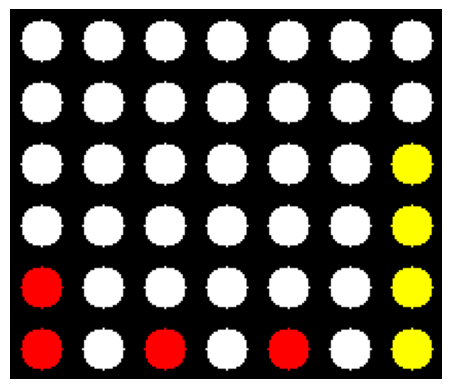

Tree Updated based on player's move


You Win!


In [ ]:
import os
import pickle
from IPython.display import clear_output
import time
from kaggle_environments import make
import numpy as np
import cv2
import matplotlib.pyplot as plt

os.chdir("/content/drive/MyDrive/AI Projects")
firstTime = False # omit this line if youve trained the model for the first time

mode = "real player" # options: ["real player", "random"]

if not firstTime:
  with open("mcts_tree.pkl", "rb") as f:
    root_node = pickle.load(f)

if not root_node.isRoot:
  raise Exception("Root node not set correctly")


connect = make("connectx", debug = True)
currNode = root_node

# used to make the agent select a move
def move(nodde):
  maxAction = []
  for i in nodde.children:
    if i == False:
      maxAct = -1*np.inf #action must never be taken
    elif i == True:
      maxAct = 0
    elif i.N == 0:
      maxAct = np.inf # expansion
    else:
      maxAct = i.Q + c*math.sqrt(math.log(nodde.N)/i.N)
    maxAction.append(maxAct)
  return int(np.argmax(maxAction)), maxAction

agentPlayer = 0 # The agent plays as red by default (like in mode = "random" case).
              # You can change this to 1 to switch to yellow
if mode == "real player":
  while True:
    turn = input("enter 1 to choose red. enter 2 to choose yellow as your piece")
    if turn == "1" or turn == "2":
      agentPlayer = abs(int(turn)-2)
      break
    else:
      print("Invalid Input")

turn = 0 #red always starts first

while connect.done == False:
  if turn == agentPlayer:
    # model learns the values of all children if these values or not present
    # to make a more informed decision when playing a certain move for the first time
    if [i for i in currNode.children if type(i) != np.bool] == []:
      for j in range(49):
        currNode.treeTraverse()
      print("Tree Updated before agent make a move")

    # make the model move
    agentAction = [None,None]
    agentMove, agentActionList = move(currNode)
    agentAction[turn] = agentMove
    # print(f"Turn {turn}: {currNode.children}, {agentActionList}, {agentMove}")
    currNode = currNode.children[agentMove]
    if type(currNode) == np.bool:
      raise Exception("agent is taking an unevaluated step")
    connect.step(agentAction)
    clear_output(wait=True)
    runBoard(connect)
    if connect.state[turn]["status"] == "INVALID":
      print(agentActionList)
      break

  else:
    if mode == "random":
      playerAction = [None,None]
      playerMove = int(np.random.choice([i for i in range(7) if connect.state[0]["observation"]["board"][i] == 0]))
      playerAction[turn] = playerMove

    elif mode == "real player":
      playerAction = [None,None]
      valid = False
      while valid == False:
        time.sleep(0.3) # this is done to ensure input functions properly
                  # input should only be asked once the board plot is closed successfully and clear_output doesnt interfere
                  # this can be ensured by setting a wait time for all the backend processes to be completed
        playerMove = input("Choose a number from 1-7 to drop a piece: ")
        try:
          playerMove = int(playerMove)-1
          valid = True if playerMove >= 0 and playerMove <= 6 else False
        except ValueError:
          print("Invalid input")
        except IndexError:
          print("Give an integer number from 1-7. Nothing beyond this range")
      playerAction[turn] = playerMove
    else:
      raise Exception("Invalid mode")

    # register the player's move
    connect.step(playerAction)
    clear_output(wait=True)
    runBoard(connect)
    if currNode == True or currNode.children[playerMove] == True:
      for j in range(49):
        currNode.treeTraverse()
      print("Tree Updated based on player's move")
    # print(f"Turn {turn}: {currNode.children}, {playerMove}")
    currNode = currNode.children[playerMove]
  turn = abs(turn-1)

connect.render(mode="ipython")

if mode == "real player":
  if connect.state[agentPlayer]["reward"] == 1:
    print("You Lost!")
  elif connect.state[agentPlayer]["reward"] == -1:
    print("You Win!")
  else:
    print("Draw")
while currNode.parent != None:
  currNode = currNode.parent

# for learning from the game played
with open("mcts_tree.pkl", "wb") as f: #creating a file in write-binary mode
  pickle.dump(currNode,f) #saves a binary version of the root node to a file (f)

connect.reset()
currNode = root_node

